## EDA: объединённый журнал System по всем машинам (all_system_logs)
Цель: оценить однородность поведения машин, выбрать общие события,
найти кандидатов в терминальные события (план работы, п. 1.1, этап 0).

**1. Загрузка данных. Общая информация**

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root_dir = Path.cwd().parent
data = root_dir / "data" / "processed" / "all_system_logs.csv"
out_dir = root_dir / "results" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_rows", 50)

df = pd.read_csv(data, dtype=str)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["pair"] = df["source"] + ":" + df["event_id"]    # компактный ключ события

print("Форма:", df.shape)
print(df.isna().sum())
print("Полных дубликатов строк:", df.duplicated().sum())
print("Период:", df["time"].min(), "-", df["time"].max())
print("Машин:", df["machine_id"].nunique())

ids = pd.to_numeric(df["event_id"], errors="coerce")
print("Максимальный event_id:", ids.max(), "| значений > 65535:", (ids > 65535).sum())



Форма: (372738, 7)
machine_id    0
time          0
event_id      0
source        0
level         0
seq           0
pair          0
dtype: int64
Полных дубликатов строк: 0
Период: 2019-10-25 18:06:54 - 2026-10-03 22:15:57
Машин: 12
Максимальный event_id: 51057 | значений > 65535: 0


**2.	Поиск дубликатов**

In [54]:
KEY = ["machine_id", "time", "event_id", "source", "level"] 
print("Копий:", df.duplicated(subset=KEY).sum())
dup_mask = df.duplicated(subset=KEY, keep=False)
print("Записей в повторяющихся группах:", dup_mask.sum())

Копий: 73954
Записей в повторяющихся группах: 101836


**3. Сводная таблица по машинам**

Полная таблица сохранена в `results/eda/machines_summary.csv`

In [55]:
summary = df.groupby("machine_id").agg(
    n_events=("event_id", "size"),
    first=("time", "min"),
    last=("time", "max"),
    n_pairs=("pair", "nunique"),
)
summary["days"] = (summary["last"] - summary["first"]).dt.total_seconds() / 86400
summary["events_per_day"] = summary["n_events"] / summary["days"]
summary = summary.sort_values("n_events", ascending=False)
summary.to_csv(out_dir / "machines_summary.csv")
summary

,n_events,first,last,n_pairs,days,events_per_day
machine_id,,,,,,
pc_11,77248,2026-08-07 21:22:03,2026-08-28 12:08:18,47,20.615451,3747.092341
pc_10,74307,2026-03-20 06:24:59,2026-05-21 08:47:37,53,62.099051,1196.588336
pc_08,44693,2024-12-31 09:20:20,2026-06-01 17:06:43,123,517.323877,86.392687
pc_01,44489,2025-11-05 11:44:47,2026-04-29 15:07:34,112,175.140822,254.018450
pc_09,43269,2026-09-11 12:45:06,2026-10-03 22:15:57,184,22.396424,1931.960243
pc_07,41194,2024-11-27 20:10:03,2026-08-22 00:03:08,107,632.161863,65.163690
pc_06,10440,2019-10-25 18:06:54,2026-05-28 18:45:39,122,2407.026910,4.337301
pc_12,9019,2024-05-19 17:17:20,2026-04-27 19:01:01,128,708.072002,12.737405
pc_03,8117,2019-10-25 18:06:54,2026-05-15 16:59:10,109,2393.952963,3.390626


**4. Уровни событий по всем машинам**

Распределение `level` (Information/Error/Warning/0), доля уровней по машинам

level
Information    171096
Error          163778
Warning         37639
0                 225
Name: count, dtype: int64


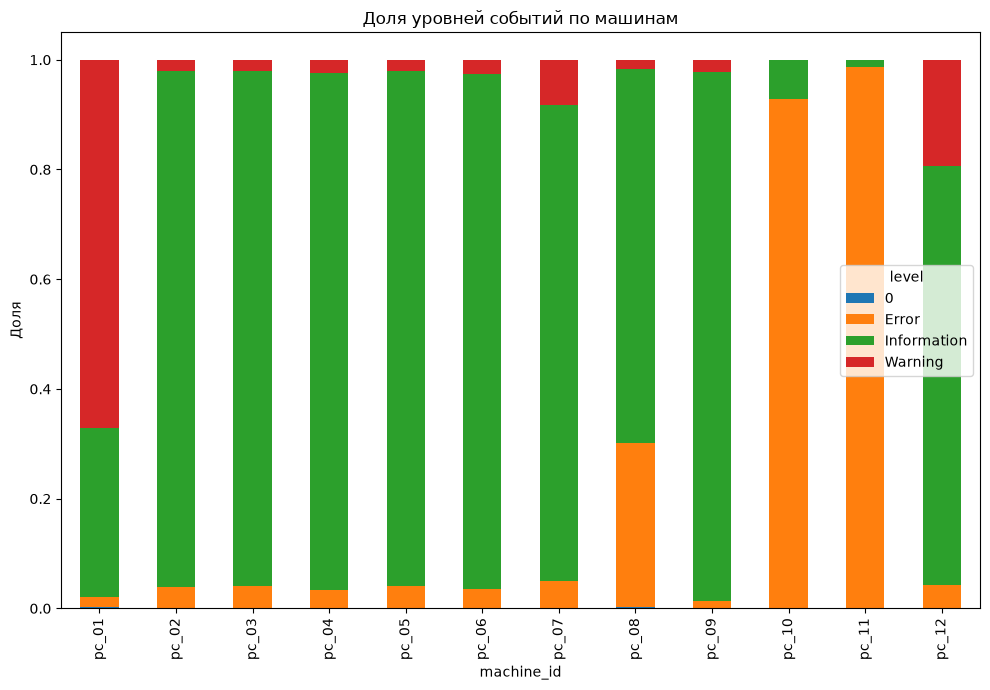

pair
Microsoft-Windows-Kernel-Power:41                    219
Microsoft-Windows-DriverFrameworks-UserMode:10110      2
Microsoft-Windows-DriverFrameworks-UserMode:10116      2
Microsoft-Windows-DriverFrameworks-UserMode:10120      1
Microsoft-Windows-DriverFrameworks-UserMode:10111      1
Name: count, dtype: int64

In [56]:
print(df["level"].value_counts(dropna=False))

lvl = pd.crosstab(df["machine_id"], df["level"], normalize="index")

lvl.plot(kind="bar", stacked=True, figsize=(10, 7))
plt.title("Доля уровней событий по машинам")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()
df[df["level"] == "0"]["pair"].value_counts()

**5. Самые частые события среди всех машин**

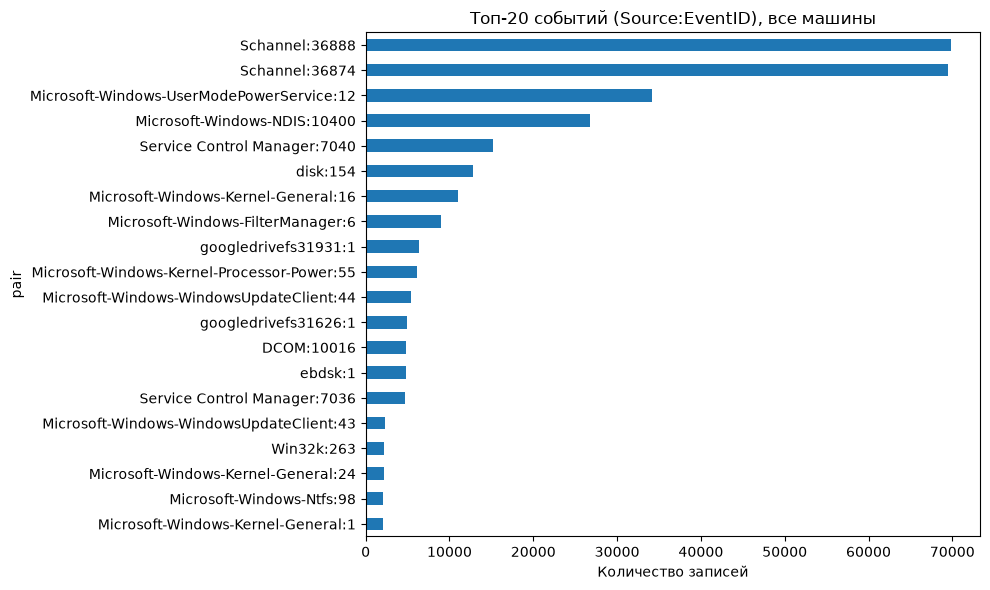

In [57]:
top = df["pair"].value_counts().head(20)
top.plot(kind="barh", figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Топ-20 событий (Source:EventID), все машины")
plt.xlabel("Количество записей")
plt.tight_layout()
plt.show()

**6. На скольких машинах встречается конкретное событие**

Полная таблица лежит в `results/eda/pair_coverage.csv`

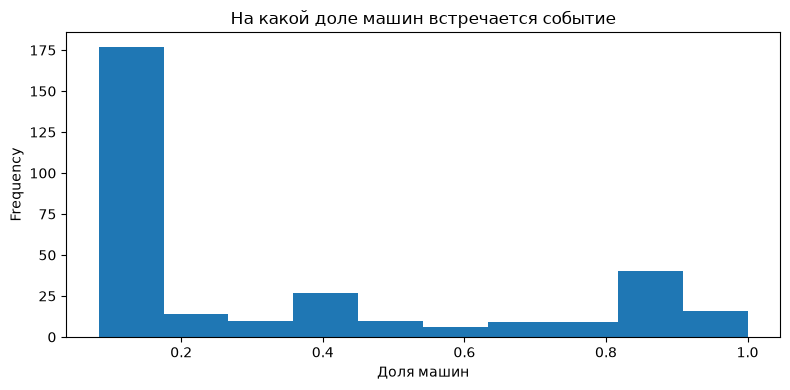

Событий на >=50% машин: 90 из 318
Они покрывают долю записей: 0.44


In [58]:
n_machines = df["machine_id"].nunique()
cov = df.groupby("pair").agg(
    n_events=("pair", "size"),
    n_machines=("machine_id", "nunique"),
)
cov["share_machines"] = cov["n_machines"] / n_machines
cov["share_events"] = cov["n_events"] / len(df)
cov = cov.sort_values("n_events", ascending=False)
cov.to_csv(out_dir / "pair_coverage.csv")

cov["share_machines"].plot(kind="hist", bins=10, figsize=(8, 4))
plt.title("На какой доле машин встречается событие")
plt.xlabel("Доля машин")
plt.tight_layout()
plt.show()

common = cov[cov["share_machines"] >= 0.5]
print("Событий на >=50% машин:", len(common), "из", len(cov))
print("Они покрывают долю записей:", round(common["share_events"].sum(), 3))

**7. События по машинам (тепловая карта)**

Одни и те же события имеют разные доли на разных машинах

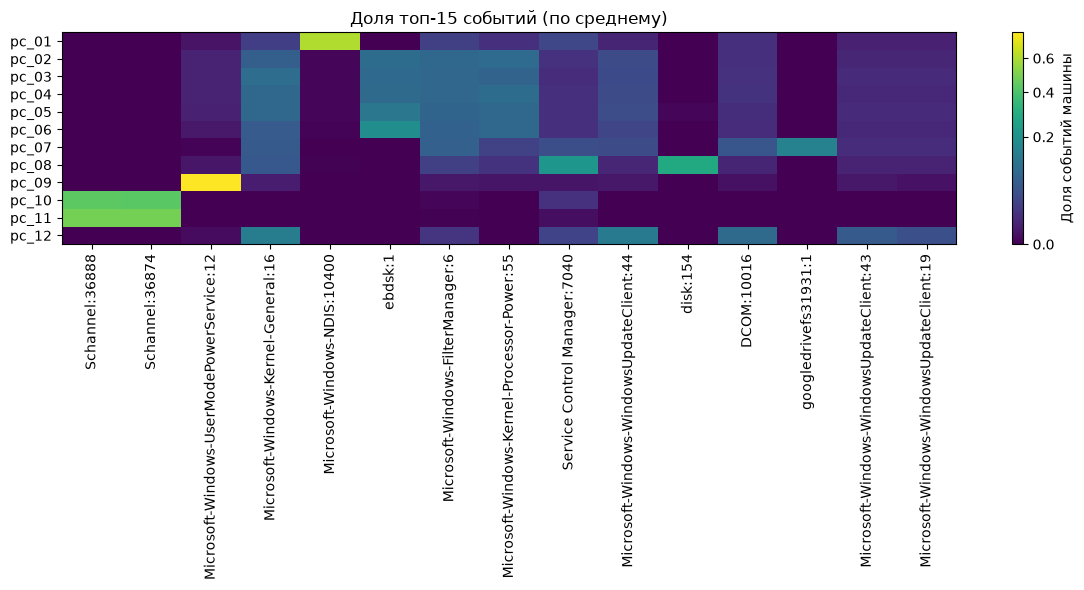

In [59]:
from matplotlib.colors import PowerNorm

share_all = (df.groupby(["machine_id", "pair"]).size().unstack(fill_value=0).div(df.groupby("machine_id").size(), axis=0))
top_pairs = share_all.mean().sort_values(ascending=False).head(15).index
share = share_all[top_pairs]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(share.values, aspect="auto", norm=PowerNorm(0.5))
ax.set_xticks(range(share.shape[1])); ax.set_xticklabels(share.columns, rotation=90)
ax.set_yticks(range(share.shape[0])); ax.set_yticklabels(share.index)
plt.colorbar(im, label="Доля событий машины")
plt.title("Доля топ-15 событий (по среднему)")
plt.tight_layout()
plt.show()

**8. Распределение собранной информации для всех машин по времени**

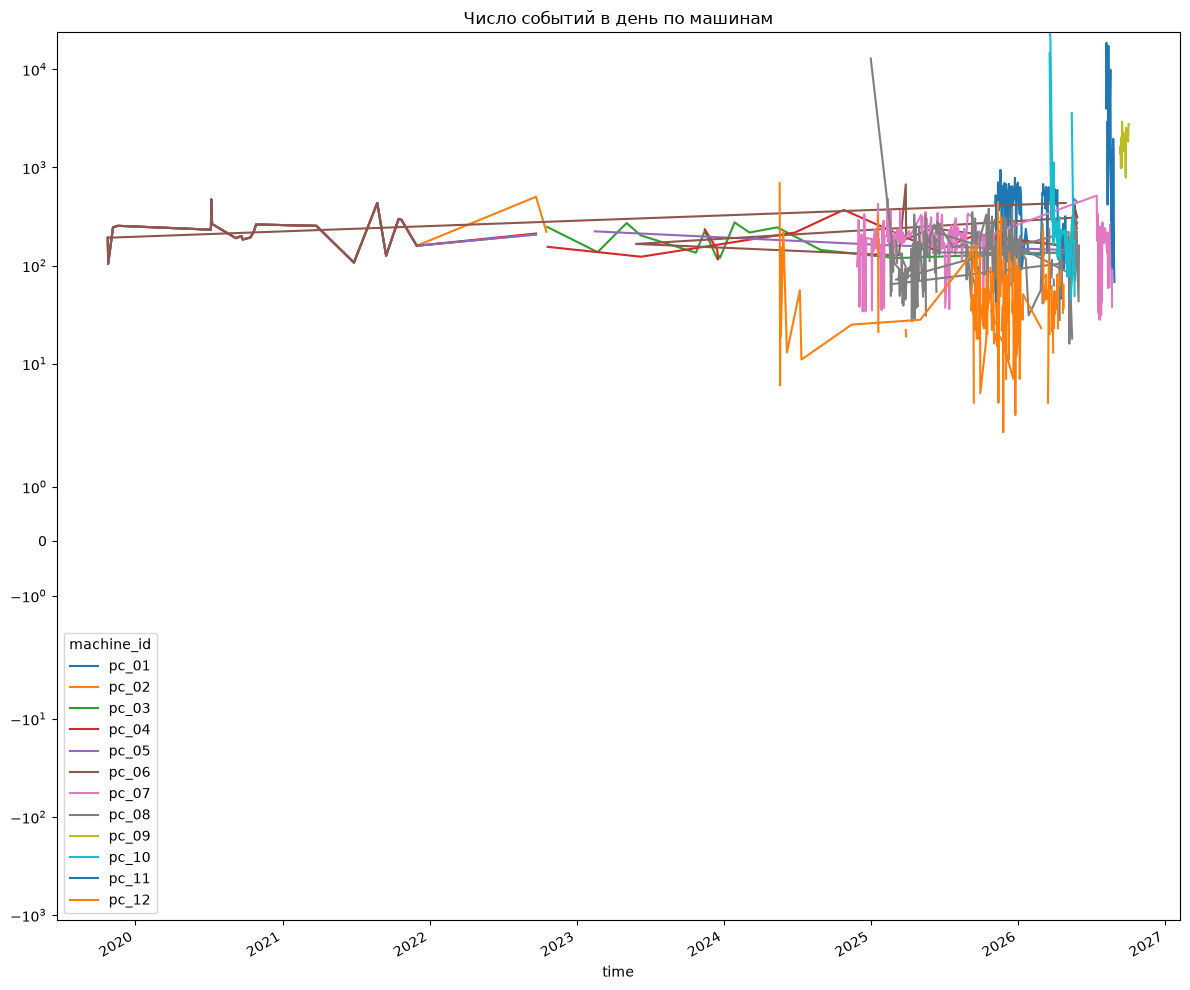

In [60]:
daily = (df.groupby(["machine_id", pd.Grouper(key="time", freq="D")])
           .size().unstack("machine_id"))
daily.plot(figsize=(12, 10))
plt.yscale("symlog")
plt.title("Число событий в день по машинам")
plt.tight_layout()
plt.show()

**9. Ошибки и критические события**

Выводит события с level `Error/0` и числом машин на которых они встречаются и сколько раз они появлялись

In [61]:
bad_levels = ["Error", "0"]

bad = df[df["level"].isin(bad_levels)]
bad_table = bad.groupby(["pair", "level"]).agg(
    n_events=("pair", "size"),
    n_machines=("machine_id", "nunique"),
).sort_values(["n_machines", "n_events"], ascending=False)
bad_table.head(30)

,,n_events,n_machines
pair,level,,
Service Control Manager:7000,Error,633,12
DCOM:10010,Error,1087,10
Service Control Manager:7009,Error,461,10
Microsoft-Windows-Kernel-Power:41,0,219,9
EventLog:6008,Error,217,9
DCOM:10005,Error,145,7
Microsoft-Windows-Bits-Client:16392,Error,8,7
Microsoft-Windows-WindowsUpdateClient:20,Error,266,6
Service Control Manager:7034,Error,51,6


**10. Завершения сессий: старт, остановка, нештатное завершение**

Полная таблица в `results/eda/session_roles_by_machine.csv`

In [62]:
    
ROLES = {
    ("Microsoft-Windows-Kernel-General", "12"): "start",
    ("Microsoft-Windows-Kernel-General", "13"): "stop_clean",
    ("Microsoft-Windows-Kernel-Power", "41"): "unexpected_shutdown",
    ("EventLog", "6008"): "unexpected_shutdown_log",
    ("User32", "1074"): "shutdown_initiated",
}
df["role"] = [ROLES.get(k) for k in zip(df["source"], df["event_id"])]

sessions = (df.dropna(subset=["role"])
              .groupby(["machine_id", "role"]).size().unstack(fill_value=0))
sessions.to_csv(out_dir / "session_roles_by_machine.csv")
sessions

role,shutdown_initiated,start,stop_clean,unexpected_shutdown,unexpected_shutdown_log
machine_id,,,,,
pc_01,70,102,7,95,95
pc_02,48,47,46,1,1
pc_03,67,67,66,1,1
pc_04,59,58,58,0,0
pc_05,60,58,58,0,0
pc_06,75,77,73,4,3
pc_07,210,212,209,3,2
pc_08,87,127,23,104,104
pc_09,4,9,4,5,5


**11. Покрытие по источникам**

In [63]:
src_cov = df.groupby("source").agg(
    n_events=("source", "size"),
    n_machines=("machine_id", "nunique"),
    n_event_ids=("event_id", "nunique"),
).sort_values("n_machines", ascending=False)
src_cov["share_events"] = src_cov["n_events"] / len(df)
src_cov.to_csv(out_dir / "source_coverage.csv")
src_cov.head(30)

,n_events,n_machines,n_event_ids,share_events
source,,,,
EventLog,4046,12,6,0.010855
Microsoft-Windows-Directory-Services-SAM,1702,12,3,0.004566
Microsoft-Windows-DNS-Client,1274,12,1,0.003418
Microsoft-Windows-Dhcp-Client,3795,12,6,0.010181
Microsoft-Windows-FilterManager,9811,12,2,0.026321
Microsoft-Windows-DHCPv6-Client,2454,12,3,0.006584
Microsoft-Windows-Time-Service,3210,12,8,0.008612
Microsoft-Windows-UserPnp,581,12,3,0.001559
Service Control Manager,22745,12,15,0.061021


**12. Самые частые события журнала System для компонент `disk`, `Microsoft-Windows-Kernel-Power`, `Service Control Manager`**

In [64]:
for src in ["disk", "Microsoft-Windows-Kernel-Power", "Service Control Manager"]:
    t = (df[df["source"] == src].groupby(["event_id", "level"]).agg(
            n_events=("pair", "size"), n_machines=("machine_id", "nunique"))
         .sort_values("n_events", ascending=False))
    print(src); print(t.head(10)); print()

disk
                  n_events  n_machines
event_id level                        
154      Error       12829           2
51       Warning       450           5
11       Error          46           5
158      Warning        30           5
7        Error           5           5

Microsoft-Windows-Kernel-Power
                      n_events  n_machines
event_id level                            
172      Information      1176           9
566      Information      1090           2
109      Information       555          10
506      Information       450           2
507      Information       448           2
42       Information       318           4
107      Information       318           4
187      Information       312           3
41       0                 219           9
125      Information       218           2

Service Control Manager
                      n_events  n_machines
event_id level                            
7040     Information     15222          12
7036     Information